In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('../artifacts/sentiment_analysis.csv')

In [3]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


## DATA preprocessing

In [4]:
data.shape

(7920, 3)

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

## Text preprocessing

In [7]:
import re
import string

In [8]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
sw = set(stopwords.words("english"))

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-zA-Z ]", "", text)       # remove punctuation & numbers
    text = " ".join(word for word in text.split() if word not in sw)
    return text

data["tweet"] = data["tweet"].apply(clean_tweet)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
data["tweet"].head(5)

0    fingerprint pregnancy test android apps beauti...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
Name: tweet, dtype: object

In [10]:
data["tweet"] = data["tweet"].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

In [11]:
data["tweet"].head(5)

0    fingerprint pregnancy test android apps beauti...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
Name: tweet, dtype: object

In [12]:
data["tweet"] = data["tweet"].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

In [13]:
def remove_numbers (text):
    text = re.sub(r'\d+','',text)
    return text

data["tweet"] = data["tweet"].apply(remove_numbers)

In [14]:
data["tweet"].tail(5)

7915    live loud lol liveoutloud selfie smile sony mu...
7916    would like wish amazing day make every minute ...
7917    helping lovely year old neighbor ipad morning ...
7918    finally got smart pocket wifi stay connected a...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

In [15]:
!pip install nltk



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import nltk

In [17]:
nltk.download('stopwords',download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [18]:
with open('../static/model/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()
    

In [19]:
data["tweet"] = data["tweet"].apply(lambda x: "  ".join(word for word in x.split() if word not in sw))


In [20]:
data["tweet"].head(5)

0    fingerprint  pregnancy  test  android  apps  b...
1    finally  transparant  silicon  case  thanks  u...
2    love  would  go  talk  makememories  unplug  r...
3    im  wired  know  im  george  made  way  iphone...
4    amazing  service  apple  wont  even  talk  que...
Name: tweet, dtype: object

In [21]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(word for word in x.split() if word not in sw))


In [26]:
!pip install wordninja
!pip install --upgrade pip


     ---------------------------------------- 0.0/541.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/541.6 kB ? eta -:--:--
     ------------------- -------------------- 262.1/541.6 kB ? eta -:--:--
     ------------------- -------------------- 262.1/541.6 kB ? eta -:--:--
     ------------------- -------------------- 262.1/541.6 kB ? eta -:--:--
     ------------------- -------------------- 262.1/541.6 kB ? eta -:--:--
     ------------------------------------ 541.6/541.6 kB 413.4 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for wordninja: filename=wordninja-2.0.0-py3-none-any.whl size=541560 sha256=0277b4437cc90d832404692e4edc67da153785ecb9674ececc57


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\User\Desktop\candle_analysis\env\Scripts\python.exe -m pip install --upgrade pip


In [27]:

import wordninja
import re, string

def clean_and_segment(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = text.lower()

    words = wordninja.split(text)
    return " ".join(words)

data["tweet"] = data["tweet"].apply(clean_and_segment)


In [28]:
data["tweet"].head(5)

0    fingerprint pregnancy test android apps beauti...
1    finally trans paran t silicon case thanks uncl...
2    love would go talk make memories unplug relax ...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
Name: tweet, dtype: object

In [29]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [30]:
data['tweet'] = data['tweet'].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [31]:
data["tweet"].head(5)

0    fingerprint pregnanc test android app beauti c...
1    final tran paran t silicon case thank uncl yay...
2    love would go talk make memori unplug relax ip...
3    im wire know im georg made way iphon cute dave...
4    amaz servic appl wont even talk question unles...
Name: tweet, dtype: object

In [32]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final tran paran t silicon case thank uncl yay...
2,3,0,love would go talk make memori unplug relax ip...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...
...,...,...,...
7915,7916,0,live loud lol live out loud self ie smile soni...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wi fi stay connect anyt...


### Building vacabulary


In [33]:
from collections import Counter
vocab = Counter()

In [34]:
for sentence in data["tweet"]:
    vocab.update(sentence.split())

In [35]:
vocab

Counter({'iphon': 5042,
         'appl': 3225,
         'samsung': 1579,
         'follow': 1389,
         'new': 1381,
         'pic': 1300,
         'insta': 1259,
         'phone': 1225,
         'twitter': 1129,
         's': 1034,
         'soni': 1027,
         'day': 984,
         'a': 835,
         'com': 778,
         'photo': 776,
         'like': 700,
         'love': 656,
         'ipad': 584,
         'i': 562,
         'x': 558,
         'rt': 547,
         'app': 543,
         'the': 539,
         'of': 538,
         'life': 534,
         'good': 517,
         'gram': 511,
         'galaxi': 509,
         'case': 486,
         'android': 474,
         'io': 432,
         'fuck': 426,
         'get': 420,
         'back': 418,
         'photographi': 404,
         'work': 363,
         'beauti': 347,
         'im': 344,
         'happi': 344,
         'cute': 342,
         'game': 335,
         'in': 335,
         'one': 332,
         'music': 330,
         'today': 319,


In [36]:
data.shape

(7920, 3)

In [37]:
tokens = [key for key in vocab if vocab[key]>10]

In [38]:
len(tokens)

1485

In [39]:
def save_vocabulary(lines, filename):
    data = '\n'.join(lines)
    file = open(filename,'w',encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, '../static/model/vacabulary.txt')

In [40]:
!pip install scikit-learn
x = data["tweet"]
y = data["label"]


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [42]:
x_train.shape

(6336,)

In [43]:
x_test.shape

(1584,)

In [44]:
import numpy as np

def vectorizer(ds, vocabulary):
    vectorized_lst = []

    for sentence in ds:
        sentence_lst = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_lst[i] = 1

        # 👇 make sure this line is OUTSIDE the inner loop
        vectorized_lst.append(sentence_lst)

    vectorized_lst_new = np.asarray(vectorized_lst, dtype=np.float32)
    return vectorized_lst_new


In [45]:
vectorized_x_train = vectorizer(x_train, tokens)

In [46]:
vectorized_x_test = vectorizer(x_test, tokens)

In [47]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6336, 1485), dtype=float32)

In [48]:
y_train

2962    0
5853    0
4918    0
3661    0
4575    0
       ..
5252    0
94      1
4564    0
2211    0
362     0
Name: label, Length: 6336, dtype: int64

In [49]:
y_train.value_counts()

label
0    4727
1    1609
Name: count, dtype: int64

In [50]:
import matplotlib.pyplot as plt
import numpy as np

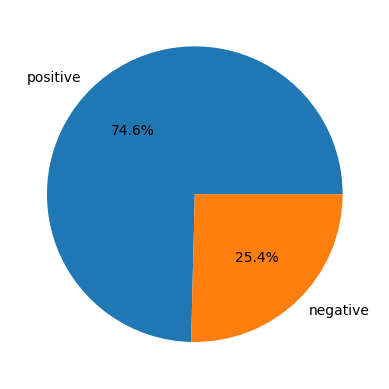

In [51]:
plt.pie(
    np.array([y_train.value_counts()[0], y_train.value_counts()[1]]),
    labels=['positive', 'negative'],
    autopct='%1.1f%%'
)
plt.show()


In [53]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)

(9454, 1485) (9454,)


In [56]:
y_train_smote.value_counts()

label
0    4727
1    4727
Name: count, dtype: int64

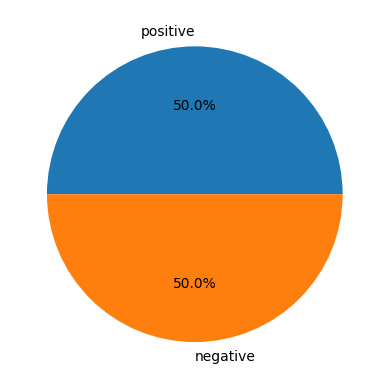

In [58]:
plt.pie(
    np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1]]),
    labels=['positive', 'negative'],
    autopct='%1.1f%%'
)
plt.show()


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [64]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def training_scores(y_act, y_pred):
    return {
        "accuracy": round(accuracy_score(y_act, y_pred), 3),
        "precision": round(precision_score(y_act, y_pred), 3),
        "recall": round(recall_score(y_act, y_pred), 3),
        "f1": round(f1_score(y_act, y_pred), 3)
    }

def validation_scores(y_act, y_pred):
    return {
        "accuracy": round(accuracy_score(y_act, y_pred), 3),
        "precision": round(precision_score(y_act, y_pred), 3),
        "recall": round(recall_score(y_act, y_pred), 3),
        "f1": round(f1_score(y_act, y_pred), 3)
    }

def print_scores(model_name, train_y, train_pred, test_y, test_pred):
    print(f"\n===== {model_name} =====")

    train = training_scores(train_y, train_pred)
    val = validation_scores(test_y, test_pred)

    print("TRAINING SCORES:")
    for k, v in train.items():
        print(f"  {k}: {v}")

    print("\nVALIDATION SCORES:")
    for k, v in val.items():
        print(f"  {k}: {v}")


In [80]:
# Train model
lr = LogisticRegression()

lr.fit(vectorized_x_train_smote, y_train_smote)

# Predictions
y_train_pred = lr.predict(vectorized_x_train_smote)
y_test_pred = lr.predict(vectorized_x_test)

# Scores
train_result = training_scores(y_train_smote, y_train_pred)
val_result = validation_scores(y_test, y_test_pred)

print("\n===== Logistic Regression =====")
print("\nTRAINING SCORES:")
for k, v in train_result.items():
    print(f"  {k}: {v}")

print("\nVALIDATION SCORES:")
for k, v in val_result.items():
    print(f"  {k}: {v}")



===== Logistic Regression =====

TRAINING SCORES:
  accuracy: 0.957
  precision: 0.94
  recall: 0.977
  f1: 0.958

VALIDATION SCORES:
  accuracy: 0.891
  precision: 0.765
  recall: 0.849
  f1: 0.805


In [82]:
ml = MultinomialNB()

# Train the NB model
ml.fit(vectorized_x_train_smote, y_train_smote)

# Predict using the SAME model (ml)
y_train_pred = ml.predict(vectorized_x_train_smote)
y_test_pred = ml.predict(vectorized_x_test)

# Scores
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)

print_scores("MultinomialNB", y_train_smote, y_train_pred, y_test, y_test_pred)



===== MultinomialNB =====
TRAINING SCORES:
  accuracy: 0.918
  precision: 0.881
  recall: 0.966
  f1: 0.922

VALIDATION SCORES:
  accuracy: 0.874
  precision: 0.7
  recall: 0.916
  f1: 0.793


In [83]:


# Create model
dt = DecisionTreeClassifier()

# Train
dt.fit(vectorized_x_train_smote, y_train_smote)

# Predictions
y_train_pred = dt.predict(vectorized_x_train_smote)
y_test_pred = dt.predict(vectorized_x_test)

# Print scores
print_scores("DecisionTreeClassifier", y_train_smote, y_train_pred, y_test, y_test_pred)



===== DecisionTreeClassifier =====
TRAINING SCORES:
  accuracy: 1.0
  precision: 1.0
  recall: 0.999
  f1: 1.0

VALIDATION SCORES:
  accuracy: 0.855
  precision: 0.717
  recall: 0.746
  f1: 0.731


In [84]:
rf = RandomForestClassifier()

# Train
rf.fit(vectorized_x_train_smote, y_train_smote)

# Predictions
y_train_pred = rf.predict(vectorized_x_train_smote)
y_test_pred = rf.predict(vectorized_x_test)

# Print scores
print_scores("RandomForestClassifier", y_train_smote, y_train_pred, y_test, y_test_pred)


===== RandomForestClassifier =====
TRAINING SCORES:
  accuracy: 1.0
  precision: 1.0
  recall: 0.999
  f1: 1.0

VALIDATION SCORES:
  accuracy: 0.884
  precision: 0.791
  recall: 0.76
  f1: 0.775


In [89]:
svc = SVC(kernel='rbf')

# Train
svc.fit(vectorized_x_train_smote, y_train_smote)

# Predictions
y_train_pred = svc.predict(vectorized_x_train_smote)
y_test_pred = svc.predict(vectorized_x_test)

# Print scores
print_scores("SVC", y_train_smote, y_train_pred, y_test, y_test_pred)


===== SVC =====
TRAINING SCORES:
  accuracy: 0.983
  precision: 0.971
  recall: 0.996
  f1: 0.983

VALIDATION SCORES:
  accuracy: 0.893
  precision: 0.781
  recall: 0.823
  f1: 0.801


In [92]:
import pickle

with open ('../static/model/model.pickle', 'wb') as file:
    pickle.dump(svc, file)